In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, BatchNormalization, Input, GRU
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.losses import Huber
from tensorflow.keras.initializers import orthogonal
from tensorflow.keras.regularizers import l2, l1, l1_l2
from scikeras.wrappers import KerasClassifier #This is for classification
from scikeras.wrappers import KerasRegressor #This is for Regression
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import RobustScaler
import yfinance as yf  # For downloading stock data
from sklearn.linear_model import LinearRegression

2025-04-20 19:46:35.404399: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Download Apple stock data (AAPL) from Yahoo Finance
stock_data = yf.download("AAPL", start="1980-12-16", end="2025-03-23")

data = pd.DataFrame(stock_data)

#data = data.drop(['Volume'],axis=1) 

#Since Volume is a strong outlier, i've noticed that the predictions are more accurate if it's dropped
#If you decide to drop it then also make sure to adjust num_features by reducing it by 1

#The original first five columns in each dataset is from the stock data downloaded online the rest are feature engineered
#The First five column from the outputs in the last cell represent the Close High Low Open

# Feature Engineering
data['Close_AVG'] = stock_data['Close'].rolling(window=5).mean().fillna(0)
data['High_AVG'] = stock_data['High'].rolling(window=5).mean().fillna(0)
data['Low_AVG'] = stock_data['Low'].rolling(window=5).mean().fillna(0)
data['Open_AVG'] = stock_data['Open'].rolling(window=5).mean().fillna(0)
data['Momentum_Close'] = stock_data['Close'].diff().fillna(0)  # Replace NaN with 0
data['Momentum_High'] = stock_data['High'].diff().fillna(0)  # Replace NaN with 0
data['Momentum_Low'] = stock_data['Low'].diff().fillna(0)  # Replace NaN with 0
data['Momentum_Open'] = stock_data['Open'].diff().fillna(0)  # Replace NaN with 0
data['Volatility_Close'] = stock_data['Close'].rolling(window=5).std().fillna(0)
data['Volatility_High'] = stock_data['High'].rolling(window=5).std().fillna(0)
data['Volatility_Low'] = stock_data['Low'].rolling(window=5).std().fillna(0)
data['Volatility_Open'] = stock_data['Open'].rolling(window=5).std().fillna(0)
data['ROC'] = (stock_data['Close'].pct_change() * 100).fillna(0)  # Rate of Change in %
data['Volume_Change'] = stock_data['Volume'].pct_change().fillna(0)
data['Close_Lag'] = stock_data['Close'].shift(1).fillna(0)
data['High_Lag'] = stock_data['High'].shift(1).fillna(0)
data['Low_Lag'] = stock_data['Low'].shift(1).fillna(0)
data['Open_Lag'] = stock_data['Open'].shift(1).fillna(0)
data['Volume_Lag1'] = data['Volume'].shift(1).fillna(0)
data['Close_Upper'] = data['Close_AVG'] + (stock_data['Close'].rolling(window=5).std().fillna(0).reindex(data.index) * 2).squeeze()
data['Close_Lower'] = data['Close_AVG'] - (stock_data['Close'].rolling(window=5).std().fillna(0) * 2).squeeze()
data['High_Upper'] = data['High_AVG'] + (stock_data['High'].rolling(window=5).std().fillna(0) * 2).squeeze()
data['High_Lower'] = data['High_AVG'] - (stock_data['High'].rolling(window=5).std().fillna(0) * 2).squeeze()
data['Low_Upper'] = data['Low_AVG'] + (stock_data['Low'].rolling(window=5).std().fillna(0) * 2).squeeze()
data['Low_Lower'] = data['Low_AVG'] - (stock_data['Low'].rolling(window=5).std().fillna(0) * 2).squeeze()
data['Open_Upper'] = data['Open_AVG'] + (stock_data['Open'].rolling(window=5).std().fillna(0) * 2).squeeze()
data['Open_Lower'] = data['Open_AVG'] - (stock_data['Open'].rolling(window=5).std().fillna(0) * 2).squeeze()


data = data.replace([np.inf, -np.inf], np.nan)
data.fillna(0, inplace=True)  # or a meaningful fill value

# Use only the 'Close' price for prediction
df_list = data.values.tolist()  
df_list = np.array(df_list, dtype=np.float64)  # Convert list to NumPy array

# Replace -inf with -257 and inf with 257
df_list[np.isneginf(df_list)] = -257
df_list[np.isposinf(df_list)] = 257

print(f"The dataframe contains Nan: {data.isna().any().any()}")
print(f"The number of Nan in my dataframe is equal to {data.isna().sum().sum()}")
print("Overall minimum value in dataframe:", data.min().min())
print("Overall maximum value in dataframe:", data.max().max())
print("Overall minimum value in Close Section:", data['Close'].min().min())
print("Overall maximum value in Close Section:", data['Close'].max().max())
print("Overall minimum value in High Section:", data['High'].min().min())
print("Overall maximum value in High Section:", data['High'].max().max())
print("Overall minimum value in Low Section:", data['Low'].min().min())
print("Overall maximum value in Low Section:", data['Low'].max().max())
print("Overall minimum value in Open Section:", data['Open'].min().min())
print("Overall maximum value in Open Section:", data['Open'].max().max())
overall_min = min([arr.min() for arr in df_list])
print("Following conversion to list the minimum value across all arrays in list:", overall_min)
overall_max = max([arr.max() for arr in df_list])
print("Following conversion to list the maximum value across all arrays in list:", overall_max)


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


The dataframe contains Nan: False
The number of Nan in my dataframe is equal to 0
Overall minimum value in dataframe: -51.86920773284094
Overall maximum value in dataframe: 7421640800.0
Overall minimum value in Close Section: 0.03777334466576576
Overall maximum value in Close Section: 258.7355041503906
Overall minimum value in High Section: 0.038202561038430664
Overall maximum value in High Section: 259.81433504408284
Overall minimum value in Low Section: 0.03777334466576576
Overall maximum value in Low Section: 257.34704665632455
Overall minimum value in Open Section: 0.038202561038430664
Overall maximum value in Open Section: 257.90642916266114
Following conversion to list the minimum value across all arrays in list: -51.86920773284094
Following conversion to list the maximum value across all arrays in list: 7421640800.0


In [3]:
sequence_length = 2
num_features = 32 #For each feature added or dropped, adjust this feature(column) by either reducing or increasing

# Create sequences of past stock prices
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

batch_one_marker = int(len(df_list) * 0.2)
batch_two_marker = int(len(df_list) * 0.3)

#Splitting the data into training, testing and validation sets
X_train_unscaled = df_list[batch_two_marker - sequence_length:].reshape(-1, num_features)
X_test_unscaled = df_list[batch_one_marker - sequence_length:batch_two_marker].reshape(-1, num_features)
X_val_unscaled = df_list[:batch_one_marker].reshape(-1, num_features)

Actual_Next_Day_Data = X_train_unscaled[-2:]

#############
# from sklearn.preprocessing import QuantileTransformer
# scaler = QuantileTransformer(output_distribution='normal')  #'uniform' or 'normal'
# X_train_scaled = scaler.fit_transform(X_train_unscaled)
# X_test_scaled = scaler.transform(X_test_unscaled)
# X_val_scaled = scaler.transform(X_val_unscaled)
#############

#############
# scaler = MinMaxScaler()  # default range = (0, 1)
# X_train_scaled = scaler.fit_transform(X_train_unscaled)
# X_test_scaled = scaler.transform(X_test_unscaled)
# X_val_scaled = scaler.transform(X_val_unscaled)
#############

#############
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train_unscaled)
# X_test_scaled = scaler.transform(X_test_unscaled)
# X_val_scaled = scaler.transform(X_val_unscaled)
#############

#############
scaler = RobustScaler(quantile_range=(1.0, 99.0))
X_train_scaled = scaler.fit_transform(X_train_unscaled)
X_test_scaled = scaler.transform(X_test_unscaled)
X_val_scaled = scaler.transform(X_val_unscaled)
next_day_scaled = scaler.transform(Actual_Next_Day_Data)
#############

#############Creating Sequences of the Data
X_train, y_train = create_sequences(X_train_scaled, sequence_length)
X_test, y_test = create_sequences(X_test_scaled, sequence_length)
val_x, val_y = create_sequences(X_val_scaled, sequence_length)
#############

prediction_data = X_train[-1] #1
Expected_result = y_train[-1] #0 X_train_unscaled[-2:] #
prediction_Data_Unseen_Day = X_train[-1] #0

print("Overall minimum value in X_train:", X_train.min().min())
print("Overall maximum value in X_train:", X_train.max().max())
print("Overall minimum value in X_test:", X_test.min().min())
print("Overall maximum value in X_test:", X_test.max().max())
print("Overall minimum value in val_x:", val_x.min().min())
print("Overall maximum value in val_x:", val_x.max().max())

X_train = X_train.reshape(X_train.shape[0], sequence_length, num_features) 
X_test = X_test.reshape(X_test.shape[0], sequence_length, num_features)
val_x = val_x.reshape(val_x.shape[0], sequence_length, num_features)
next_day_scaled = next_day_scaled.reshape(sequence_length,-1)

# Print the shapes
print(f"Train shape x: {X_train.shape}, Test shape x: {y_train.shape}")
print(f"Validation shape x: {X_test.shape}, Validation shape y: {y_test.shape}")
print(f"Train shape y: {val_x.shape}, Test shape y: {val_y.shape}")

Overall minimum value in X_train: -3.617608748595635
Overall maximum value in X_train: 5.979212844644279
Overall minimum value in X_test: -1.6120510145119404
Overall maximum value in X_test: 20.59265946146681
Overall minimum value in val_x: -1.7727948385214203
Overall maximum value in val_x: 47.3202354472682
Train shape x: (7810, 2, 32), Test shape x: (7810, 32)
Validation shape x: (1116, 2, 32), Validation shape y: (1116, 32)
Train shape y: (2229, 2, 32), Test shape y: (2229, 32)


In [4]:
model = Sequential([
    Input(shape=(sequence_length, num_features)),
    LSTM(1200, return_sequences=True, kernel_initializer='glorot_normal', activity_regularizer=l2(0.001), recurrent_initializer=orthogonal()), # Second LSTM layer     
    Dropout(0.6),
    LSTM(1200, return_sequences=False, kernel_initializer='glorot_normal', activity_regularizer=l2(0.001), recurrent_initializer=orthogonal()), # Second LSTM layer 
    Dropout(0.6),
    Dense(1100, activation='relu'),  # Fully connected layer
    Dropout(0.5),
    Dense(1000, activation='relu'),  # Fully connected layer
    Dense(num_features, activation='linear')  # Output layer (predicting 19 values representing each feature)
    ])

# Compile the model
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss=Huber(delta=0.5), metrics=['mae'])
model.summary()
history = model.fit(X_train, y_train, 
               epochs=5, 
               batch_size=32, 
               validation_data=(val_x, val_y))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 2, 1200)        │     5,918,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 1200)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1200)           │    11,524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1100)           │     1,321,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1100)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1000)           │     1,101,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │        32,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,897,332 (75.90 MB)

 Trainable params: 19,897,332 (75.90 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
245/245 ━━━━━━━━━━━━━━━━━━━━ 110s 431ms/step - loss: 0.0190 - mae: 0.0876 - val_loss: 0.0039 - val_mae: 0.0289
Epoch 2/5
245/245 ━━━━━━━━━━━━━━━━━━━━ 179s 734ms/step - loss: 0.0042 - mae: 0.0379 - val_loss: 0.0030 - val_mae: 0.0200
Epoch 3/5
245/245 ━━━━━━━━━━━━━━━━━━━━ 133s 540ms/step - loss: 0.0037 - mae: 0.0344 - val_loss: 0.0027 - val_mae: 0.0167
Epoch 4/5
245/245 ━━━━━━━━━━━━━━━━━━━━ 139s 566ms/step - loss: 0.0035 - mae: 0.0332 - val_loss: 0.0026 - val_mae: 0.0170
Epoch 5/5
245/245 ━━━━━━━━━━━━━━━━━━━━ 142s 578ms/step - loss: 0.0034 - mae: 0.0323 - val_loss: 0.0025 - val_mae: 0.0163


35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - loss: 0.0019 - mae: 0.0150
MAE: 0.02 and the Test Loss is: 0.00
(1, 2, 32)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 827ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
This is the scaled prediction_data [[[ 0.91318642  0.91866439  0.91458959  0.90914101 -0.11948178
    0.90153101  0.90532564  0.90100828  0.90654593  0.30693266
    0.49718466  0.30324579  0.00690823  0.41391098  0.36822396
    0.39813165  0.32381363  0.0788856   0.11363762  0.90208818
    0.90311247  0.90467248  0.90890372 -0.12642763  0.89515371
    0.90682108  0.89856269  0.91373384  0.89363641  0.90563921
    0.89600321  0.91507527]
  [ 0.90821871  0.91318779  0.90786728  0.90813833 -0.12269089
    0.90537419  0.90588538  0.90434723  0.90483846 -0.13737736
   -0.17499224 -0.2057186  -0.02728603  0.17453746  0.38788984
    0.32618403  0.23149858 -0.04151906 -0.02976993  0.91320018
    0.91867997  0.91460215  0.90916529 -0.11948178  0.88914204
    0.92103505  0.89990759  0.91346844  0.89384863

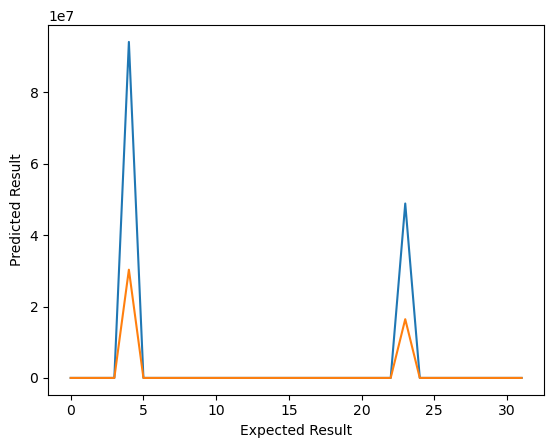

||||||||||||||||||||||||||This is the prediction for the New Day||||||||||||||||||||||||||||||||
[[ 2.1245824e+02  2.1348497e+02  2.0989906e+02  2.1271950e+02
   4.1409152e+07  2.1274940e+02  2.1462520e+02  2.0924702e+02
   2.1075220e+02 -2.2542116e-01  9.7719751e-02  6.5944009e-02
   3.5371527e-01  2.3822076e+00  2.1203568e+00  2.2313442e+00
   2.1660464e+00 -2.1615233e-01  8.7444067e-02  2.1171603e+02
   2.1478645e+02  2.0978891e+02  2.1156259e+02  3.0929440e+07
   2.1612572e+02  2.0614874e+02  2.1878540e+02  2.0819968e+02
   2.1744637e+02  2.0643559e+02  2.1625124e+02  2.0696078e+02]]


In [5]:
test_loss, mae = model.evaluate(X_test, y_test)
print(f"MAE: {mae:.2f} and the Test Loss is: {test_loss:.2f}")

#Predicting the result of the reduced hyperparameter tuning and Inverse transforming predictions

prediction_data = np.expand_dims(prediction_data, axis=0)  # Add batch dimension to make it (1, sequence_length, num_features) 
print(prediction_data.shape) #printing out the shape of the data we're using to make predictions
predicted = model.predict(prediction_data)
predicted_prices = scaler.inverse_transform(predicted)
pre_prediction = scaler.inverse_transform(prediction_data.reshape(-1,num_features)) 
Expected_result = scaler.inverse_transform(Expected_result.reshape(-1,num_features))

#New day
next_day_expanded = np.expand_dims(next_day_scaled, axis=0)
newDayPrediction = model.predict(next_day_expanded)
newDayPrediction_Prices = scaler.inverse_transform(newDayPrediction)
#New day

Diff_result = Expected_result - predicted_prices
print(f"This is the scaled prediction_data {prediction_data}")
print(f"This is the prediction Data {pre_prediction}\n")
print(f"This is the predicted price {predicted_prices}")
print(f"This is the Expected Price {Expected_result}")
print(f"This is the difference between the expected and predicted price {Diff_result}")
plt.plot(Expected_result[0])
plt.plot(predicted_prices[0])
plt.xlabel("Expected Result")
plt.ylabel("Predicted Result")
plt.show()

print("||||||||||||||||||||||||||This is the prediction for the New Day||||||||||||||||||||||||||||||||")
print(newDayPrediction_Prices)